In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix
import json
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
def load_dataset(directory, image_size=(128, 128), batch_size=32, shuffle=True, seed=None):
    """Load and preprocess the dataset from directory"""
    return tf.keras.utils.image_dataset_from_directory(
        directory,
        labels="inferred",
        label_mode="categorical",
        batch_size=batch_size,
        image_size=image_size,
        shuffle=shuffle,
        seed=seed,
        interpolation="bilinear",
        verbose=True
    )

In [ ]:
full_dataset = load_dataset('/content/drive/MyDrive/Banana/TrainingSet')

Found 1600 files belonging to 4 classes.


In [ ]:
from tqdm import tqdm

def dataset_to_numpy(dataset):
    """Convert TF Dataset to numpy arrays with a progress bar"""
    images, labels = [], []
    total_batches = tf.data.experimental.cardinality(dataset).numpy()

    for img, lbl in tqdm(dataset, total=total_batches, desc="Converting dataset"):
        images.append(img.numpy())
        labels.append(lbl.numpy())

    return np.concatenate(images), np.concatenate(labels)

# Usage
X, y = dataset_to_numpy(full_dataset)


Converting dataset: 100%|██████████| 50/50 [05:21<00:00,  6.44s/it]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPool2D, Dropout,Flatten, Dense

def create_model(input_shape=(128, 128, 3), num_classes=4):
    """Create and compile the CNN model"""
    model = Sequential()
    return model

# Call the create_model function to initialize the model
input_shape = (128, 128, 3)  # Define input_shape
model = create_model(input_shape=input_shape) # Assign the created model to the variable 'model'

# Now you can add layers to the model
model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=input_shape))
model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=2, strides=2))
model.add(Dropout(0.32))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=2,strides=2))
model.add(Dropout(0.32))

In [ ]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=2,strides=2))
model.add(Dropout(0.32))

In [ ]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=2,strides=2))
model.add(Dropout(0.32))

In [ ]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=2,strides=2))
model.add(Dropout(0.32))

In [ ]:
model.add(Flatten())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.32))
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.32))
model.add(Dense(4, activation='softmax'))

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
import os

dataset_path = "/content/drive/MyDrive/Banana/TrainingSet"


print("Classes found:", os.listdir(dataset_path))

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    if len(os.listdir(class_path)) == 0:
        print(f"⚠️ Warning: Folder '{class_name}' is empty!")

Classes found: ['cordana', 'healthy', 'pestalotiopsis', 'sigatoka']


In [ ]:
import imghdr

dataset_path = "/content/drive/MyDrive/Banana/TrainingSet"


for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        if imghdr.what(img_path) is None:
            print(f"❌ Removing corrupt file: {img_path}")
            os.remove(img_path)

<ipython-input-15-029cb2c0edb2>:1: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [ ]:
import hashlib
dataset_path = "/content/drive/MyDrive/Banana/TrainingSet"
hashes = set()

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        # Compute hash of the image
        with open(img_path, 'rb') as f:
            img_hash = hashlib.md5(f.read()).hexdigest()

        # Check if duplicate
        if img_hash in hashes:
            print(f"❌ Duplicate found! Removing: {img_path}")
            os.remove(img_path)
        else:
            hashes.add(img_hash)

❌ Duplicate found! Removing: /content/drive/MyDrive/Banana/TrainingSet/cordana/129_aug.jpeg
❌ Duplicate found! Removing: /content/drive/MyDrive/Banana/TrainingSet/cordana/171_aug.jpeg
❌ Duplicate found! Removing: /content/drive/MyDrive/Banana/TrainingSet/cordana/21_aug.jpeg
❌ Duplicate found! Removing: /content/drive/MyDrive/Banana/TrainingSet/cordana/8_aug.jpeg
❌ Duplicate found! Removing: /content/drive/MyDrive/Banana/TrainingSet/healthy/145_aug.jpeg
❌ Duplicate found! Removing: /content/drive/MyDrive/Banana/TrainingSet/healthy/150_aug.jpeg
❌ Duplicate found! Removing: /content/drive/MyDrive/Banana/TrainingSet/healthy/151_aug.jpeg
❌ Duplicate found! Removing: /content/drive/MyDrive/Banana/TrainingSet/healthy/258_aug.jpeg
❌ Duplicate found! Removing: /content/drive/MyDrive/Banana/TrainingSet/healthy/269_aug.jpeg
❌ Duplicate found! Removing: /content/drive/MyDrive/Banana/TrainingSet/healthy/281_aug.jpeg
❌ Duplicate found! Removing: /content/drive/MyDrive/Banana/TrainingSet/healthy/31_a

In [ ]:
num_folds = 5
kfold = KFold(n_splits=num_folds, shuffle=True, random_state=42)

In [ ]:
fold_results = {
    'train_acc': [],
    'val_acc': [],
    'train_loss': [],
    'val_loss': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'histories': [],
    'confusion_matrices':[],
    'sensitivity': [], 'specificity': [], 'per_class_precision': [], 'accuracy': []
}

In [ ]:
print(f"\nStarting {num_folds}-fold cross validation...\n")

for fold, (train_ids, val_ids) in enumerate(kfold.split(X, y)):
    print(f"\n{'='*40}")
    print(f"Training Fold {fold + 1}/{num_folds}")
    print(f"{'='*40}")

    X_train, y_train = X[train_ids], y[train_ids]
    X_val, y_val = X[val_ids], y[val_ids]

    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).prefetch(tf.data.AUTOTUNE)
    val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(32).prefetch(tf.data.AUTOTUNE)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint(
            f"best_model_fold_{fold+1}.keras",
            save_best_only=True,
            monitor='val_accuracy'
        )
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=20,
        callbacks=callbacks,
        verbose=1
    )

    # Evaluate on validation set for metrics
    y_val_pred_probs = model.predict(val_ds)
    y_val_pred = np.argmax(y_val_pred_probs, axis=1)

    y_val_true = np.concatenate([y for x, y in val_ds], axis=0)
    y_val_true = np.argmax(y_val_true, axis=1)

    cm = confusion_matrix(y_val_true, y_val_pred)
    fold_results['confusion_matrices'].append(cm)

    precision = precision_score(y_val_true, y_val_pred, average='macro')
    recall = recall_score(y_val_true, y_val_pred, average='macro')
    f1 = f1_score(y_val_true, y_val_pred, average='macro')
    # True Positives, False Positives, False Negatives, True Negatives
    TP = np.diag(cm)
    FP = np.sum(cm, axis=0) - TP
    FN = np.sum(cm, axis=1) - TP
    TN = np.sum(cm) - (TP + FP + FN)

    sensitivity = TP / (TP + FN + 1e-10)  # Recall
    specificity = TN / (TN + FP + 1e-10)
    precision = TP / (TP + FP + 1e-10)
    accuracy = np.sum(TP) / np.sum(cm)

    # Save results
    fold_results['train_acc'].append(history.history['accuracy'][-1])
    fold_results['val_acc'].append(history.history['val_accuracy'][-1])
    fold_results['train_loss'].append(history.history['loss'][-1])
    fold_results['val_loss'].append(history.history['val_loss'][-1])
    fold_results['precision'].append(precision)
    fold_results['recall'].append(recall)
    fold_results['f1'].append(f1)
    fold_results['histories'].append(history.history)
    fold_results['sensitivity'].append(sensitivity)
    fold_results['specificity'].append(specificity)
    fold_results['per_class_precision'].append(precision)
    fold_results['accuracy'].append(accuracy)


    model.save(f"best_model_fold_{fold+1}.keras")



Starting 5-fold cross validation...


Training Fold 1/5
Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 29s 157ms/step - accuracy: 0.4160 - loss: 5.8535 - val_accuracy: 0.2469 - val_loss: 35.8779
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 22s 90ms/step - accuracy: 0.4823 - loss: 1.7102 - val_accuracy: 0.2500 - val_loss: 3.5828
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.5509 - loss: 1.1887 - val_accuracy: 0.3688 - val_loss: 1.6271
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.6153 - loss: 0.9166 - val_accuracy: 0.3281 - val_loss: 2.3495
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.6723 - loss: 0.8614 - val_accuracy: 0.2969 - val_loss: 3.0709
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.6520 - loss: 0.8275 - val_accuracy: 0.4031 - val_loss: 2.0103
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step

Training Fold 2/5
Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.6368 - loss: 0.8551 - val_accuracy: 0.3219 - val_loss

In [ ]:
class_names = full_dataset.class_names
class_names

['cordana', 'healthy', 'pestalotiopsis', 'sigatoka']


=== Average Metrics per Class over 5 Folds ===
Class cordana:
  Sensitivity (Recall): 0.6700
  Specificity        : 0.9231
  Precision          : 0.8446
Class healthy:
  Sensitivity (Recall): 0.8706
  Specificity        : 0.8609
  Precision          : 0.6869
Class pestalotiopsis:
  Sensitivity (Recall): 0.6288
  Specificity        : 0.8664
  Precision          : 0.6197
Class sigatoka:
  Sensitivity (Recall): 0.7051
  Specificity        : 0.9739
  Precision          : 0.8938

=== Overall Average Accuracy over 5 Folds ===
Average Accuracy: 0.7188

Detailed Cross Validation Metrics Per Fold:
------------------------------------------------------------
Fold 1:
  Train Accuracy     : 0.6773
  Validation Accuracy: 0.4031
  Train Loss         : 0.8268
  Validation Loss    : 2.0103
  Precision (macro)  : 0.4627
  Recall (macro)     : 0.3754
  F1-Score (macro)   : 0.3427
  Confusion Matrix:
[[50  4 20  1]
 [27 41 12  0]
 [43 28 17  1]
 [17 24 25 10]]


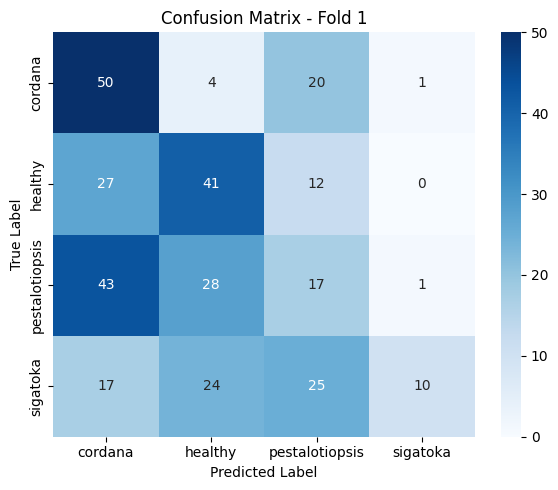

------------------------------------------------------------
Fold 2:
  Train Accuracy     : 0.8852
  Validation Accuracy: 0.6125
  Train Loss         : 0.3559
  Validation Loss    : 1.5782
  Precision (macro)  : 0.7876
  Recall (macro)     : 0.7230
  F1-Score (macro)   : 0.7098
  Confusion Matrix:
[[27  5 42  6]
 [ 0 75  5  0]
 [ 1 18 64  1]
 [ 0  2  9 65]]


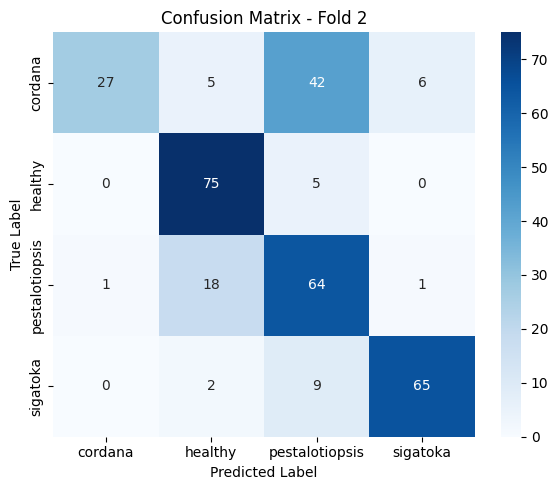

------------------------------------------------------------
Fold 3:
  Train Accuracy     : 0.8836
  Validation Accuracy: 0.6687
  Train Loss         : 0.3466
  Validation Loss    : 0.9115
  Precision (macro)  : 0.7676
  Recall (macro)     : 0.7178
  F1-Score (macro)   : 0.7166
  Confusion Matrix:
[[42 17 10  9]
 [ 0 79  4  0]
 [ 3 31 38  1]
 [ 0  7  5 74]]


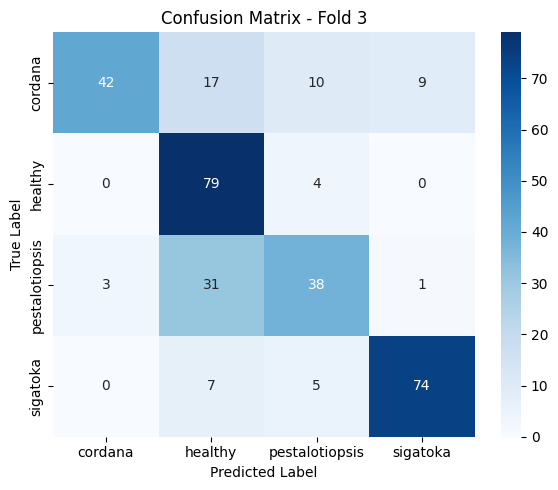

------------------------------------------------------------
Fold 4:
  Train Accuracy     : 0.9281
  Validation Accuracy: 0.8031
  Train Loss         : 0.1971
  Validation Loss    : 1.0127
  Precision (macro)  : 0.8546
  Recall (macro)     : 0.8500
  F1-Score (macro)   : 0.8450
  Confusion Matrix:
[[73  4  1 11]
 [ 0 70  1  0]
 [ 1 18 56  0]
 [ 1  4  8 72]]


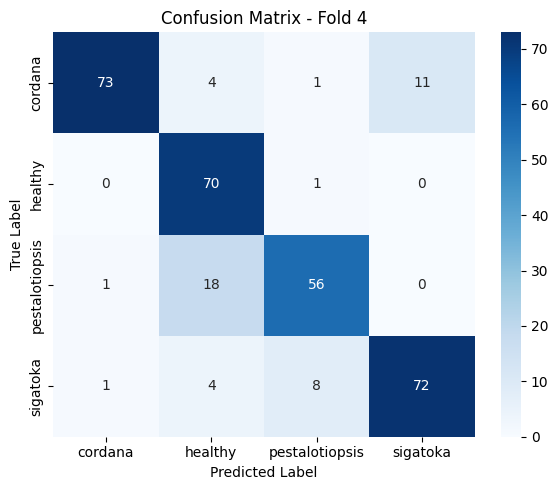

------------------------------------------------------------
Fold 5:
  Train Accuracy     : 0.9523
  Validation Accuracy: 0.8406
  Train Loss         : 0.1505
  Validation Loss    : 0.8023
  Precision (macro)  : 0.9338
  Recall (macro)     : 0.9269
  F1-Score (macro)   : 0.9279
  Confusion Matrix:
[[77  0  1  0]
 [ 0 83  3  0]
 [ 0  5 73  1]
 [ 1  0 12 64]]


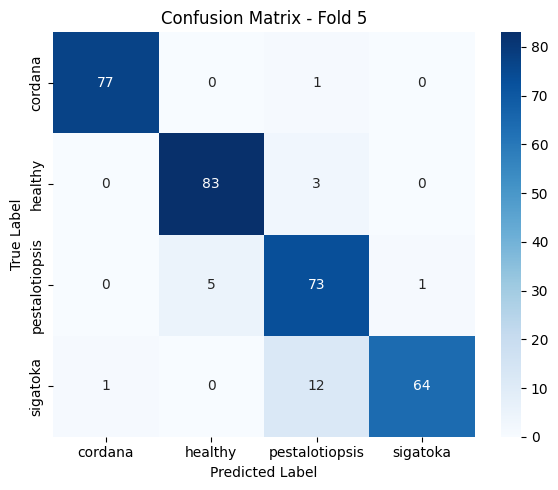

------------------------------------------------------------


In [ ]:
# Convert lists to arrays
sensitivities = np.array(fold_results['sensitivity'])
specificities = np.array(fold_results['specificity'])
precisions_per_class = np.array(fold_results['per_class_precision'])
accuracies_per_fold = np.array(fold_results['accuracy'])

# Averages across folds
avg_sensitivity = np.mean(sensitivities, axis=0)
avg_specificity = np.mean(specificities, axis=0)
avg_precision_per_class = np.mean(precisions_per_class, axis=0)
avg_accuracy = np.mean(accuracies_per_fold)

# Display average metrics per class
print("\n=== Average Metrics per Class over 5 Folds ===")
for i, class_name in enumerate(class_names):
    print(f"Class {class_name}:")
    print(f"  Sensitivity (Recall): {avg_sensitivity[i]:.4f}")
    print(f"  Specificity        : {avg_specificity[i]:.4f}")
    print(f"  Precision          : {avg_precision_per_class[i]:.4f}")

# Overall accuracy
print(f"\n=== Overall Average Accuracy over 5 Folds ===")
print(f"Average Accuracy: {avg_accuracy:.4f}")
print("="*60)
# Detailed metrics per fold
print("\nDetailed Cross Validation Metrics Per Fold:")
print(f"{'-'*60}")
for i in range(num_folds):
    print(f"Fold {i+1}:")
    print(f"  Train Accuracy     : {fold_results['train_acc'][i]:.4f}")
    print(f"  Validation Accuracy: {fold_results['val_acc'][i]:.4f}")
    print(f"  Train Loss         : {fold_results['train_loss'][i]:.4f}")
    print(f"  Validation Loss    : {fold_results['val_loss'][i]:.4f}")
    print(f"  Precision (macro)  : {np.mean(fold_results['precision'][i]):.4f}")
    print(f"  Recall (macro)     : {fold_results['recall'][i]:.4f}")
    print(f"  F1-Score (macro)   : {fold_results['f1'][i]:.4f}")
    print("  Confusion Matrix:")
    cm = fold_results['confusion_matrices'][i]
    print(cm)

    # Plot confusion matrix for the current fold
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - Fold {i + 1}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    print("-" * 60)


In [ ]:
# Print summary
print("\nCross Validation Results Summary:")
print(f"{'-'*40}")
for metric in ['train_acc', 'val_acc', 'train_loss', 'val_loss', 'precision', 'recall', 'f1']:
    print(f"Average {metric.replace('_', ' ').title()}: {np.mean(fold_results[metric]):.4f} ± {np.std(fold_results[metric]):.4f}")

# # Save results
# with open("cross_validation_results.json", "w") as f:
#     json.dump(fold_results, f)


Cross Validation Results Summary:
----------------------------------------
Average Train Acc: 0.8653 ± 0.0976
Average Val Acc: 0.6656 ± 0.1557
Average Train Loss: 0.3754 ± 0.2397
Average Val Loss: 1.2630 ± 0.4596
Average Precision: 0.7613 ± 0.2188
Average Recall: 0.7186 ± 0.1889
Average F1: 0.7084 ± 0.2003


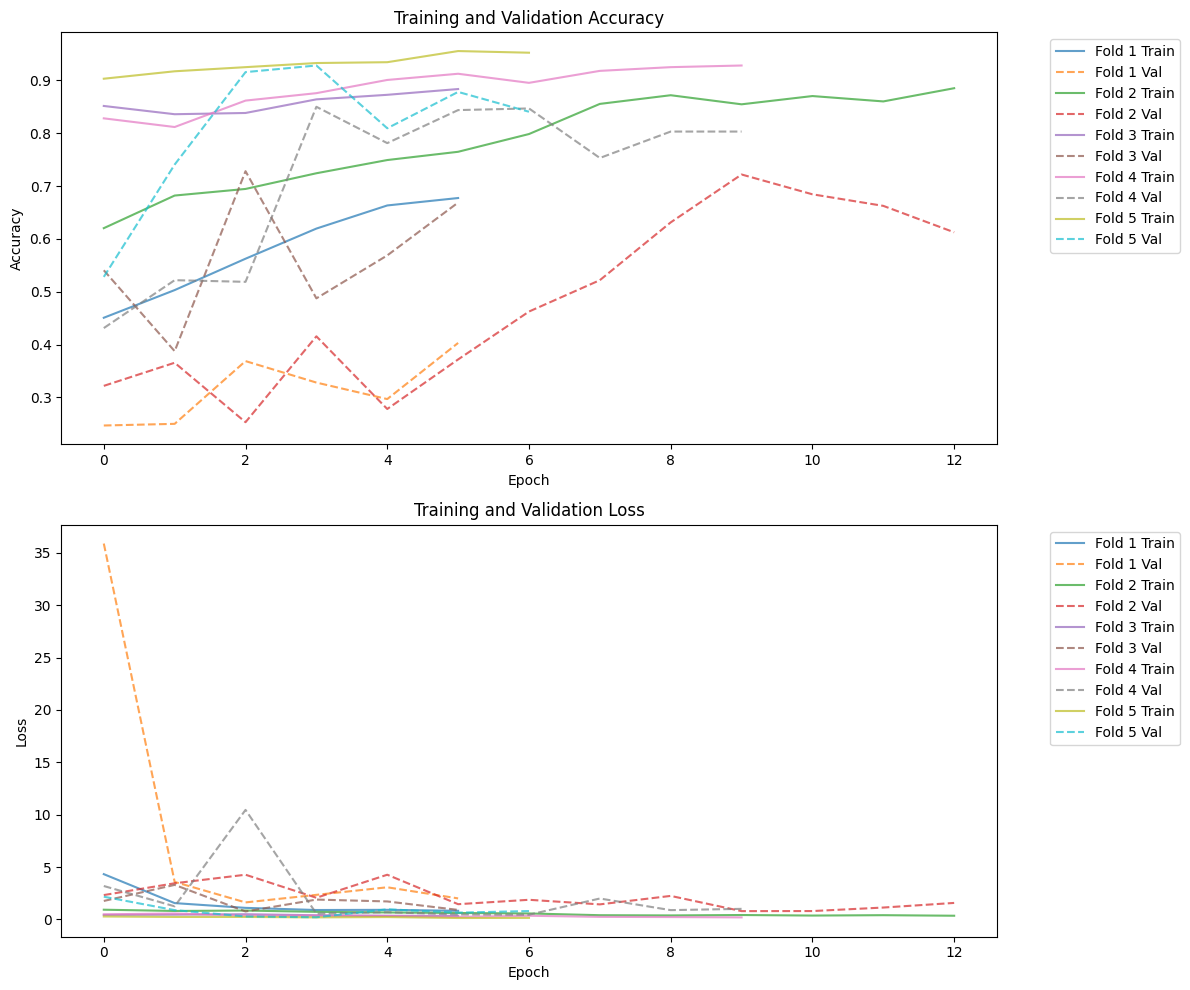

In [ ]:
# Plot learning curves
def plot_learning_curves(histories):
    plt.figure(figsize=(12, 10))

    # Accuracy
    plt.subplot(2, 1, 1)
    for i, history in enumerate(histories):
        plt.plot(history['accuracy'], label=f'Fold {i+1} Train', alpha=0.7)
        plt.plot(history['val_accuracy'], '--', label=f'Fold {i+1} Val', alpha=0.7)
    plt.title('Training and Validation Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # Loss
    plt.subplot(2, 1, 2)
    for i, history in enumerate(histories):
        plt.plot(history['loss'], label=f'Fold {i+1} Train', alpha=0.7)
        plt.plot(history['val_loss'], '--', label=f'Fold {i+1} Val', alpha=0.7)
    plt.title('Training and Validation Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

plot_learning_curves(fold_results['histories'])


In [ ]:
# Load best model based on val accuracy
best_fold = np.argmax(fold_results['val_acc'])
print(f'\nUsing model from fold {best_fold+1} (best validation accuracy) for final test evaluation')

best_model = tf.keras.models.load_model(f"best_model_fold_{best_fold+1}.keras")



Using model from fold 5 (best validation accuracy) for final test evaluation


In [ ]:
from PIL import Image
import os

test_folder = '/content/drive/MyDrive/Banana/OriginalSet'
corrupted_files = []

for root, dirs, files in os.walk(test_folder):
    for file in files:
        file_path = os.path.join(root, file)
        try:
            img = Image.open(file_path)
            img.verify()
        except Exception as e:
            corrupted_files.append(file_path)

print(f"Found {len(corrupted_files)} corrupted files.")

for file_path in corrupted_files:
    os.remove(file_path)
    print(f"Deleted: {file_path}")

/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.11/dist-packages/PIL/JpegImagePlugin.py:890: UserWarning: Image appears to be a malformed MPO file, it will be interpreted as a base JPEG file
  warnings.warn(


Found 0 corrupted files.


In [ ]:
# Test evaluation
test_set = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/Banana/OriginalSet',
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False
)

class_names = test_set.class_names
test_loss, test_acc = best_model.evaluate(test_set)
print(f'\nTest Accuracy: {test_acc:.4f}')
print(f'Test Loss: {test_loss:.4f}')

Found 937 files belonging to 4 classes.
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 156ms/step - accuracy: 0.9025 - loss: 0.4033

Test Accuracy: 0.8986
Test Loss: 0.4044


In [ ]:
y_pred = best_model.predict(test_set)
predicted_categories = tf.argmax(y_pred, axis=1)
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

print('\nClassification Report:')
print(classification_report(Y_true, predicted_categories, target_names=class_names))


30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step

Classification Report:
                precision    recall  f1-score   support

       cordana       0.94      0.91      0.93       162
       healthy       0.88      0.94      0.91       129
pestalotiopsis       0.71      0.91      0.80       173
      sigatoka       0.99      0.88      0.93       473

      accuracy                           0.90       937
     macro avg       0.88      0.91      0.89       937
  weighted avg       0.91      0.90      0.90       937



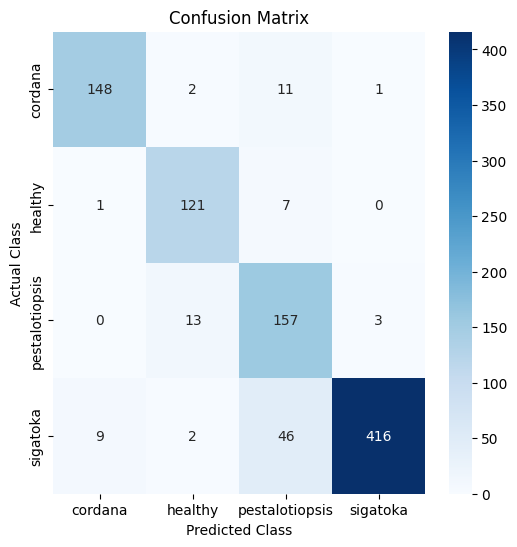

In [ ]:
# Confusion matrix
cm = confusion_matrix(Y_true, predicted_categories)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")
plt.show()